In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Trump\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Trump\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Trump\AppData\Roaming\nltk_data...


True

In [2]:
!python -m pip install --upgrade pip

In [3]:
!"C:\Users\Trump\CA DataScience\DataScience\Machine Learning\.venv\Scripts\python.exe" -m pip install --upgrade pip

In [4]:
!pip install pandas numpy scikit-learn nltk matplotlib wordcloud jupyter

In [5]:
import pandas as pd

df = pd.read_json(r"C:\Users\Trump\Sentiment-Analysis-NLP-ML\data\imdb_reviews.json")

df.head()

,title,description,date_created,datasets
name.basics.tsv.gz,IMDb Datasets,"Comprehensive IMDb datasets including title, n...",2026-05-13,"{'total_records': 1000000, 'columns': ['nconst..."
title.akas.tsv.gz,IMDb Datasets,"Comprehensive IMDb datasets including title, n...",2026-05-13,"{'total_records': 1000000, 'columns': ['titleI..."
title.basics.tsv.gz,IMDb Datasets,"Comprehensive IMDb datasets including title, n...",2026-05-13,"{'total_records': 1000000, 'columns': ['tconst..."
title.crew.tsv.gz,IMDb Datasets,"Comprehensive IMDb datasets including title, n...",2026-05-13,"{'total_records': 1000000, 'columns': ['tconst..."
title.episode.tsv.gz,IMDb Datasets,"Comprehensive IMDb datasets including title, n...",2026-05-13,"{'total_records': 1000000, 'columns': ['tconst..."


In [6]:
df.info

<bound method DataFrame.info of                                  title  \
name.basics.tsv.gz       IMDb Datasets   
title.akas.tsv.gz        IMDb Datasets   
title.basics.tsv.gz      IMDb Datasets   
title.crew.tsv.gz        IMDb Datasets   
title.episode.tsv.gz     IMDb Datasets   
title.principals.tsv.gz  IMDb Datasets   
title.ratings.tsv.gz     IMDb Datasets   

                                                               description  \
name.basics.tsv.gz       Comprehensive IMDb datasets including title, n...   
title.akas.tsv.gz        Comprehensive IMDb datasets including title, n...   
title.basics.tsv.gz      Comprehensive IMDb datasets including title, n...   
title.crew.tsv.gz        Comprehensive IMDb datasets including title, n...   
title.episode.tsv.gz     Comprehensive IMDb datasets including title, n...   
title.principals.tsv.gz  Comprehensive IMDb datasets including title, n...   
title.ratings.tsv.gz     Comprehensive IMDb datasets including title, n...   

      

In [7]:
print(df.columns)

Index(['title', 'description', 'date_created', 'datasets'], dtype='str')


In [8]:
!pip install datasets

In [9]:
import sys
!"{sys.executable}" -m pip install datasets

In [10]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset['train'])

train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [11]:
train_df['sentiment'] = train_df['label'].map({
    0: 'negative',
    1: 'positive'
})

In [12]:
train_df['sentiment'].value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

In [13]:
train_df.columns

Index(['text', 'label', 'sentiment'], dtype='str')

In [14]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       25000 non-null  str  
 1   label      25000 non-null  int64
 2   sentiment  25000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 32.4 MB


In [15]:
train_df.isnull().sum()

text         0
label        0
sentiment    0
dtype: int64

In [16]:
train_df['sentiment'].value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

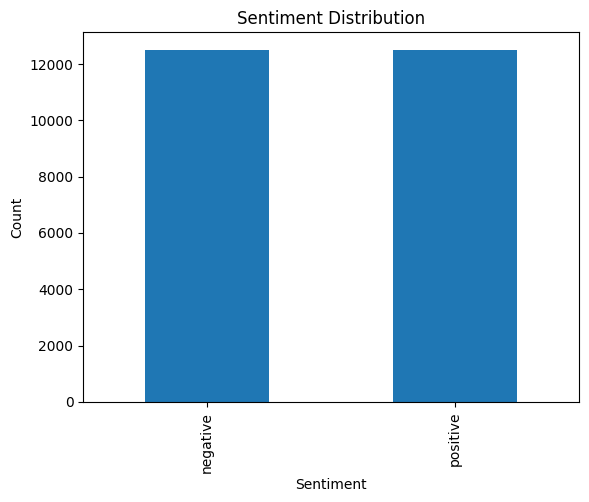

In [17]:
import matplotlib.pyplot as plt

train_df['sentiment'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.show()

In [18]:
train_df['review_length'] = train_df['text'].apply(len)

In [19]:
train_df['review_length'].describe()

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review_length, dtype: float64

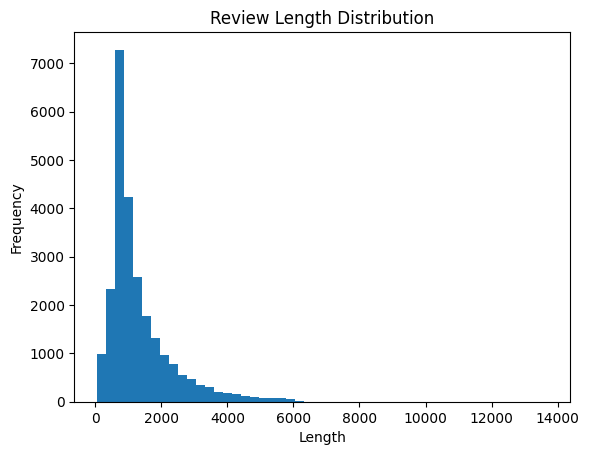

In [20]:
import matplotlib.pyplot as plt

plt.hist(train_df['review_length'], bins=50)

plt.title('Review Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.show()

In [21]:
positive_reviews = train_df[train_df['sentiment'] == 'positive']
negative_reviews = train_df[train_df['sentiment'] == 'negative']

print("Positive Avg Length:",
      positive_reviews['review_length'].mean())

print("Negative Avg Length:",
      negative_reviews['review_length'].mean())

Positive Avg Length: 1347.16024
Negative Avg Length: 1302.97904


In [22]:
!pip install wordcloud

In [23]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [24]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Trump\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Trump\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [25]:
stop_words = set(stopwords.words('english'))

In [26]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # remove punctuation/numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # tokenize
    words = word_tokenize(text)

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    # join back into sentence
    text = ' '.join(words)

    return text

In [27]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Trump\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [28]:
train_df['cleaned_text'] = train_df['text'].apply(clean_text)

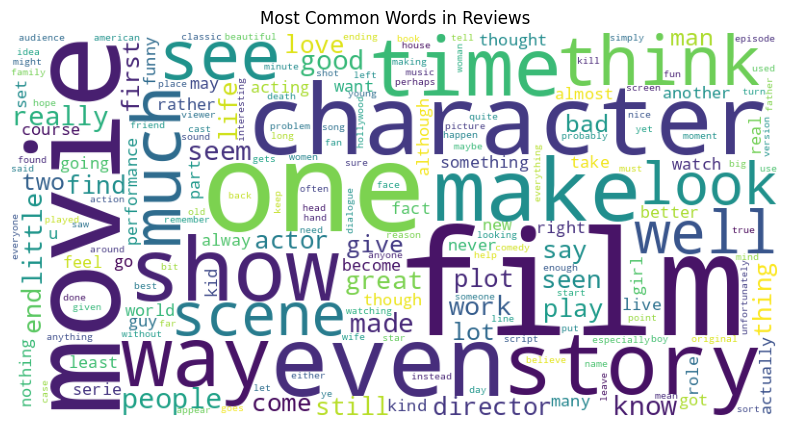

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned reviews into one large string
all_words = ' '.join(train_df['cleaned_text'])

# Create WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

# Display WordCloud
plt.figure(figsize=(10, 5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Most Common Words in Reviews')

plt.show()

In [30]:
!pip install streamlit

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(train_df['cleaned_text'])

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(train_df['cleaned_text'])

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    train_df['label'],
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": log_model,
    "Naive Bayes": nb_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8842,0.873433,0.896982,0.885051
1,Naive Bayes,0.8532,0.848111,0.858350,0.853200
2,Random Forest,0.8500,0.850789,0.846680,0.848729


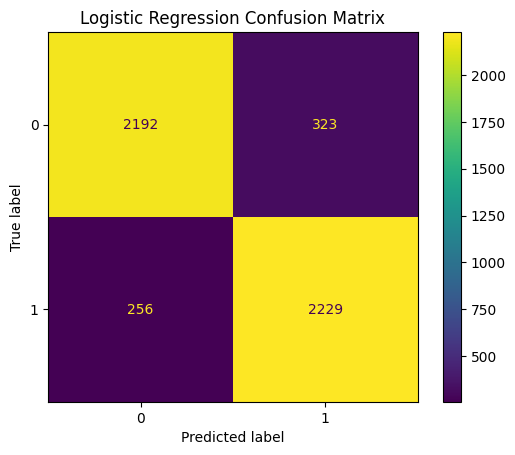

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = log_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

The Logistic Regression model correctly classified 2,192 negative reviews and 2,229 positive reviews. The model made relatively few mistakes, with 323 false positives and 256 false negatives. This demonstrates strong classification performance and confirms the effectiveness of the TF-IDF feature representation combined with Logistic Regression.

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      2515
           1       0.87      0.90      0.89      2485

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



In [53]:
X = X_tfidf
y = train_df['label']

In [54]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    log_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.8594 0.8602 0.8588 0.8714 0.8622]
Mean CV Accuracy: 0.8624


In [55]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
CountVectorizer          type                      <class 'sklearn.feature_e<...>on.text.CountVectorizer'>
GridSearchCV             ABCMeta                   <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
MultinomialNB            ABCMeta                   <class 'sklearn.naive_bayes.MultinomialNB'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
TfidfVectorizer          type                      <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
WordCloud                type                      <class 'wordcloud.wordcloud.WordCloud'>
WordNetLemmatizer        type                     

In [56]:
cv_scores = cross_val_score(
    log_model,
    X_tfidf,
    train_df['label'],
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.8594 0.8602 0.8588 0.8714 0.8622]
Mean CV Accuracy: 0.8624


In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 1}
Best CV Score: 0.8806499999999999


In [58]:
def predict_sentiment(review: str) -> str:
    # Preprocess the input text (use your existing clean_text function if you have one)
    cleaned_review = clean_text(review)
    
    # Transform using the same TF-IDF vectorizer
    review_vector = tfidf.transform([cleaned_review])
    
    # Predict sentiment (1 = positive, 0 = negative)
    prediction = grid.best_estimator_.predict(review_vector)
    
    return "Positive" if prediction[0] == 1 else "Negative"

In [59]:
print(predict_sentiment("This film was fantastic!"))
print(predict_sentiment("I really didn’t enjoy this movie."))

Positive
Positive
